In [8]:
# =====================================================================
# 1. SETUP, LOAD & BRUTAL CLEANING
# =====================================================================
import pandas as pd
import numpy as np

# Load data
df_trav = pd.read_csv(r"C:\Users\gmitr\OneDrive\Documents\ML Project Reply\MIB-Man-in-Big-Data\src\io\TRAVELERS_CLEAN.csv")
df_alar = pd.read_csv(r"C:\Users\gmitr\OneDrive\Documents\ML Project Reply\MIB-Man-in-Big-Data\src\io\ALARMS_CLEAN.csv")

# Brutal but effective cleaning (Travelers)
df_trav = df_trav.drop(columns=['operator_notes', 'risk_code', 'control_outcome'], errors='ignore')
df_trav = df_trav.dropna(subset=['departure_date'])
df_trav[['document_type', 'gender']] = df_trav[['document_type', 'gender']].fillna('N.D.')
for col in ['zone', 'entries', 'investigated', 'alarms']:
    df_trav[col] = df_trav[col].fillna(df_trav[col].median())

# Brutal but effective cleaning (Alarms)
df_alar = df_alar.dropna(subset=['DEPARTURE_DATE'])
cols_to_fill = ['DEPARTURE_AIRPORT_DESCRIPTION', 'DEPARTURE_CITY', 'DEPARTURE_COUNTRY_CODE']
df_alar[cols_to_fill] = df_alar[cols_to_fill].fillna('N.D.')
df_alar['TOTAL_FLIGHTS'] = df_alar['TOTAL_FLIGHTS'].fillna(df_alar['TOTAL_FLIGHTS'].median())


print(f"Missing values left: {df_trav.isna().sum().sum()}")
print(f"Missing values left: {df_alar.isna().sum().sum()}")

Missing values left: 0
Missing values left: 0


In [9]:
# =====================================================================
# 2. TEMPORAL ALIGNMENT & RICH AGGREGATION (THE PIVOT)
# =====================================================================
# 1. Convert to date only (YYYY-MM-DD)
df_trav['merge_date'] = pd.to_datetime(df_trav['departure_date']).dt.normalize()
df_alar['merge_date'] = pd.to_datetime(df_alar['DEPARTURE_DATE']).dt.normalize()

# 2. Extract Alarm Reasons and Risk Flags into binary columns (One-Hot Encoding)
# If a row is an "INTERPOL" alarm, it gets a 1 in the INTERPOL column, etc.
alarms_dummies = pd.get_dummies(df_alar[['ALARM_REASON', 'RISK_FLAG']])

# Combine dates, airports, and these new binary columns
df_alar_rich = pd.concat([df_alar[['merge_date', 'DEPARTURE_AIRPORT_IATA']], alarms_dummies], axis=1)

# 3. Aggregate: Sum up each type of alarm per day/airport
alarms_grouped = df_alar_rich.groupby(['merge_date', 'DEPARTURE_AIRPORT_IATA']).sum().reset_index()

# 4. Also calculate the grand total of alarms for that day/airport
total_counts = df_alar.groupby(['merge_date', 'DEPARTURE_AIRPORT_IATA']).size().reset_index(name='total_alarms_day')

# Merge the rich details with the grand total
alarms_grouped = pd.merge(alarms_grouped, total_counts, on=['merge_date', 'DEPARTURE_AIRPORT_IATA'])



In [11]:
# =====================================================================
# 3. THE MERGE (CREATING THE MASTER DATASET)
# =====================================================================
# Join Travelers with our new, rich aggregated Alarms
df_master = pd.merge(
    df_trav, 
    alarms_grouped, 
    left_on=['merge_date', 'departure_airport_iata'], 
    right_on=['merge_date', 'DEPARTURE_AIRPORT_IATA'], 
    how='left'
)

# Replace NaNs with 0 for flights that had NO alarms at all
cols_to_fill = [col for col in df_master.columns if 'ALARM_REASON' in col or 'RISK_FLAG' in col or col == 'total_alarms_day']
df_master[cols_to_fill] = df_master[cols_to_fill].fillna(0)

# Drop redundant columns
df_master = df_master.drop(columns=['DEPARTURE_AIRPORT_IATA', 'merge_date'], errors='ignore')

print(f"MASTER DATASET READY: {df_master.shape[0]} rows, {df_master.shape[1]} columns")
display(df_master.head())

MASTER DATASET READY: 4689 rows, 37 columns


,nationality,arrival_airport_iata,departure_airport_iata,departure_year,departure_month,departure_day,departure_date,arrival_airport_description,departure_airport_description,arrival_city,...,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,ALB,NAP,DUR,2024,2,13,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ALB,FCO,JFK,2024,1,22,2024-01-22 16:35:00,FIUMICINO,JOHN F KENNEDY INTERNATIONAL,ROMA,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,ALB,TSF,TIA,2024,2,4,2024-02-04 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,...,0.0,1.0,2.0,5.0,2.0,2.0,0.0,12.0,0.0,12.0
3,AFG,FCO,IST,2024,1,25,2024-01-25 13:05:00,FIUMICINO,HAVALIMANI,ROMA,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,0.0,3.0
4,ALB,TSF,LTN,2024,2,18,2024-02-18 16:30:00,TREVISO-SANT'ANGELO,LONDON LUTON,TREVISO,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0


In [12]:
# =====================================================================
# 4. FEATURE ENGINEERING (BASELINES & RATIOS)
# =====================================================================
import numpy as np
from sklearn.ensemble import IsolationForest

# 1. Temporal feature: Is it a weekend?
df_master['day_of_week'] = pd.to_datetime(df_master['departure_date']).dt.dayofweek
df_master['is_weekend'] = np.where(df_master['day_of_week'] >= 5, 1, 0)

# 2. The Golden Feature: Alarm Rate (%)
df_master['alarm_rate'] = np.where(
    df_master['entries'] > 0, 
    df_master['total_alarms_day'] / df_master['entries'], 
    0
)

# 3. The Baseline: Historical average rate per Departure Airport
airport_baseline = df_master.groupby('departure_airport_iata')['alarm_rate'].mean().reset_index()
airport_baseline.rename(columns={'alarm_rate': 'airport_historical_avg_rate'}, inplace=True)
df_master = pd.merge(df_master, airport_baseline, on='departure_airport_iata', how='left')

# 4. The Anomaly Indicator: Deviation from the usual baseline
df_master['rate_deviation'] = df_master['alarm_rate'] - df_master['airport_historical_avg_rate']

print("Features created: alarm_rate, airport_historical_avg_rate, rate_deviation")

Features created: alarm_rate, airport_historical_avg_rate, rate_deviation


In [13]:
# =====================================================================
# 4.bis FEATURE ENGINEERING (TIME SERIES ADDITIONS)
# =====================================================================

# 1. CRITICAL: Sort data chronologically per airport before doing time math
df_master = df_master.sort_values(by=['departure_airport_iata', 'departure_date'])

# 2. Lag Feature: What was the alarm rate yesterday for this airport?
df_master['alarm_rate_yesterday'] = df_master.groupby('departure_airport_iata')['alarm_rate'].shift(1)

# 3. Rolling Average: What is the trend over the last 7 days?
# We use min_periods=1 so the first few days don't turn into NaNs
df_master['rolling_7d_avg_rate'] = df_master.groupby('departure_airport_iata')['alarm_rate'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# 4. Fill the NaNs created by the shift (the very first day has no "yesterday")
# We fill it with the historical average as a neutral fallback
df_master['alarm_rate_yesterday'] = df_master['alarm_rate_yesterday'].fillna(df_master['airport_historical_avg_rate'])

print("Time Series Features created: alarm_rate_yesterday, rolling_7d_avg_rate")

Time Series Features created: alarm_rate_yesterday, rolling_7d_avg_rate


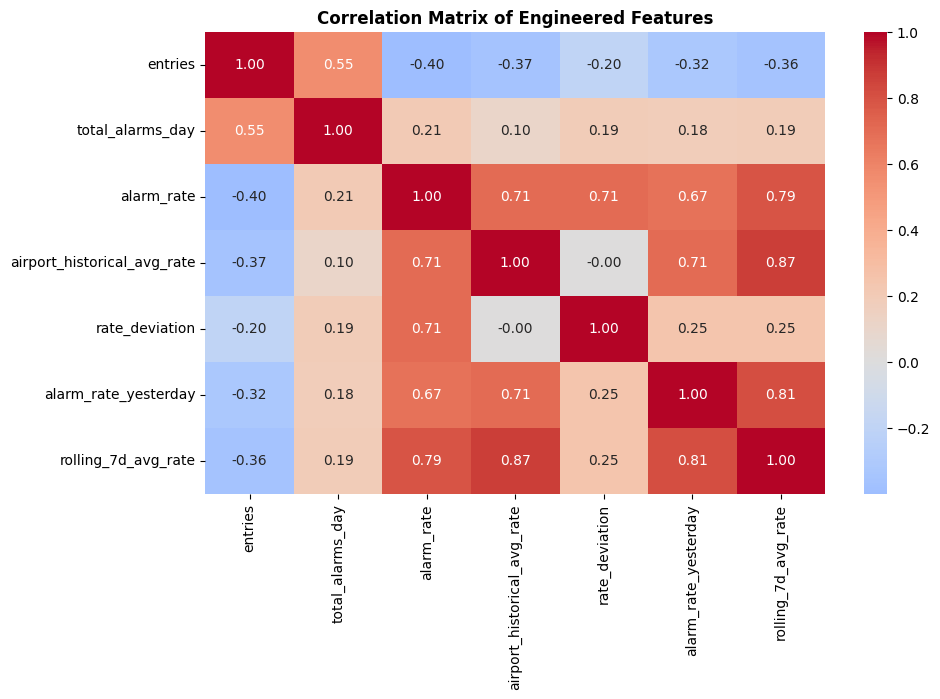

In [14]:
# =====================================================================
# 5. FEATURE SELECTION: MULTICOLLINEARITY CHECK
# =====================================================================
import seaborn as sns
import matplotlib.pyplot as plt

# Select the features we engineered
engineered_features = [
    'entries', 
    'total_alarms_day', 
    'alarm_rate', 
    'airport_historical_avg_rate',
    'rate_deviation', 
    'alarm_rate_yesterday', 
    'rolling_7d_avg_rate'
]

# Calculate correlation matrix
corr = df_master[engineered_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Matrix of Engineered Features", fontweight='bold')
plt.show()

In [18]:
# =====================================================================
# 8. FINAL FEATURE ENGINEERING: TRAFFIC BASELINE & COLUMN CHECK
# =====================================================================
import numpy as np

# 1. Traffic Baseline: What is the normal volume of passengers for this airport?
traffic_baseline = df_master.groupby('departure_airport_iata')['entries'].mean().reset_index()
traffic_baseline.rename(columns={'entries': 'airport_historical_avg_entries'}, inplace=True)
df_master = pd.merge(df_master, traffic_baseline, on='departure_airport_iata', how='left')

# 2. Traffic Deviation: Is today's volume unusually high or low?
df_master['traffic_multiplier'] = np.where(
    df_master['airport_historical_avg_entries'] > 0,
    df_master['entries'] / df_master['airport_historical_avg_entries'],
    0
)

# 3. Clean up any Math artifacts (Infinity values)
df_master = df_master.replace([np.inf, -np.inf], 0)
df_master.fillna(0, inplace=True)

# 4. REASSURANCE: Show all columns we currently have
print("=" * 70)
print(f"FINAL DATASET SHAPE: {df_master.shape[0]} rows, {df_master.shape[1]} columns")
print("=" * 70)

# 5. Let's look at the best ML-ready features we built
# REMOVED 'nat_historical_risk_score' to fix the KeyError
best_features = [
    'entries', 
    'traffic_multiplier',         
    'rate_deviation',             
    'rolling_7d_avg_rate',        
    'RISK_FLAG_HIGH'              
]

print("\n--- PREVIEW OF THE CORE FEATURES FOR THE ALGORITHM ---")
display(df_master[['departure_airport_iata', 'departure_date'] + best_features].head(10))

FINAL DATASET SHAPE: 4689 rows, 48 columns

--- PREVIEW OF THE CORE FEATURES FOR THE ALGORITHM ---


,departure_airport_iata,departure_date,entries,traffic_multiplier,rate_deviation,rolling_7d_avg_rate,RISK_FLAG_HIGH
0,ABJ,2024-02-03 13:00:00,1.0,1.000000,0.000,0.000000,0.0
1,ADB,2024-01-01 11:45:00,1.0,0.727273,-0.125,0.000000,0.0
2,ADB,2024-01-05 08:00:00,2.0,1.454545,-0.125,0.000000,0.0
3,ADB,2024-01-08 11:10:00,1.0,0.727273,0.875,0.333333,0.0
4,ADB,2024-01-15 11:45:00,2.0,1.454545,-0.125,0.250000,0.0
5,ADB,2024-01-15 11:45:00,2.0,1.454545,-0.125,0.200000,0.0
6,ADB,2024-01-29 11:45:00,1.0,0.727273,-0.125,0.166667,0.0
7,ADB,2024-02-01 09:15:00,1.0,0.727273,-0.125,0.142857,0.0
8,ADB,2024-02-01 11:45:00,1.0,0.727273,-0.125,0.142857,0.0
9,ADD,2024-02-19 09:15:00,1.0,1.000000,0.000,0.000000,0.0


In [19]:
# =====================================================================
# 9. FEATURE SELECTION (AVOIDING THE CURSE OF DIMENSIONALITY)
# =====================================================================
# Strategy: We reduce our 48 columns down to 7 highly informative features.
# - We remove raw text and IDs (Algorithm cannot process them).
# - We remove redundant features to avoid Multicollinearity (e.g., keeping 
#   'rate_deviation' but dropping raw 'alarm_rate').
# - We mix raw context ('entries') with smart baselines ('traffic_multiplier').

final_features = [
    'entries',               # Context: Raw passenger volume
    'total_alarms_day',      # Context: Raw alarm volume
    'traffic_multiplier',    # Signal: Abnormal passenger spikes (Volume Baseline)
    'rate_deviation',        # Signal: Deviation from usual alarm rate (Risk Baseline)
    'rolling_7d_avg_rate',   # Signal: Recent time-series trend (Temporal Baseline)
    'RISK_FLAG_HIGH',        # Signal: Presence of severe alarms (Business value)
    'is_weekend'             # Context: Weekly seasonality
]

print("--- SELECTED FEATURES FOR THE ISOLATION FOREST ---")
for i, f in enumerate(final_features):
    print(f"{i+1}. {f}")

# Create a clean sub-dataframe specifically for the Machine Learning model
# We fill any sneaky NaNs with 0 to prevent the algorithm from crashing
X_train = df_master[final_features].copy()
X_train = X_train.fillna(0)

print(f"\nModel-ready dataset shape: {X_train.shape[0]} rows, {X_train.shape[1]} features.")

--- SELECTED FEATURES FOR THE ISOLATION FOREST ---
1. entries
2. total_alarms_day
3. traffic_multiplier
4. rate_deviation
5. rolling_7d_avg_rate
6. RISK_FLAG_HIGH
7. is_weekend

Model-ready dataset shape: 4689 rows, 7 features.


In [21]:
# =====================================================================
# 10. MACHINE LEARNING: ISOLATION FOREST EXECUTION
# =====================================================================
from sklearn.ensemble import IsolationForest

print("Initializing and training the Isolation Forest model...")

# 1. Initialize the model
# contamination=0.03 means we ask the model to flag the top 3% weirdest days
iso_forest = IsolationForest(
    n_estimators=100,       # Number of trees in the forest
    contamination=0.03,     # Expected proportion of anomalies
    random_state=42,        # For reproducible results
    n_jobs=-1               # Use all available CPU cores
)

# 2. Train the model and predict
# Result is an array where 1 = Normal, -1 = Anomaly
df_master['anomaly_label'] = iso_forest.fit_predict(X_train)

# 3. Calculate Anomaly Severity Score
# decision_function returns negative values for anomalies. We multiply by -1 
# so that a HIGHER positive number means a WORSE anomaly.
df_master['anomaly_severity_score'] = iso_forest.decision_function(X_train) * -1

# =====================================================================
# 11. EXTRACTING AND SORTING THE RESULTS
# =====================================================================
# Filter the master dataset to only show the detected anomalies
df_anomalies = df_master[df_master['anomaly_label'] == -1]

# Sort them from most abnormal to least abnormal
df_anomalies = df_anomalies.sort_values(by='anomaly_severity_score', ascending=False)

print(f"Success! The model analyzed {len(X_train)} records and found {len(df_anomalies)} anomalies.")
print("\n" + "=" * 80)
print("TOP 5 MOST ANOMALOUS FLIGHTS/DAYS ALERTS")
print("=" * 80)

# Display a clean summary for human review
display_cols = [
    'departure_date', 
    'departure_airport_iata', 
    'anomaly_severity_score', 
    'entries', 
    'total_alarms_day', 
    'rate_deviation', 
    'traffic_multiplier'
]
display(df_anomalies[display_cols].head(5))

Initializing and training the Isolation Forest model...
Success! The model analyzed 4689 records and found 141 anomalies.

TOP 5 MOST ANOMALOUS FLIGHTS/DAYS ALERTS


,departure_date,departure_airport_iata,anomaly_severity_score,entries,total_alarms_day,rate_deviation,traffic_multiplier
2968,2024-01-11 05:35:00,TIA,0.107238,1.0,20.0,19.314382,0.012795
2966,2024-01-11 05:35:00,TIA,0.087829,1.0,20.0,19.314382,0.012795
3106,2024-01-14 16:55:00,TIA,0.085592,1.0,11.0,10.314382,0.012795
2663,2024-01-04 05:35:00,TIA,0.082936,2.0,17.0,7.814382,0.025589
3104,2024-01-14 16:55:00,TIA,0.079738,1.0,11.0,10.314382,0.012795


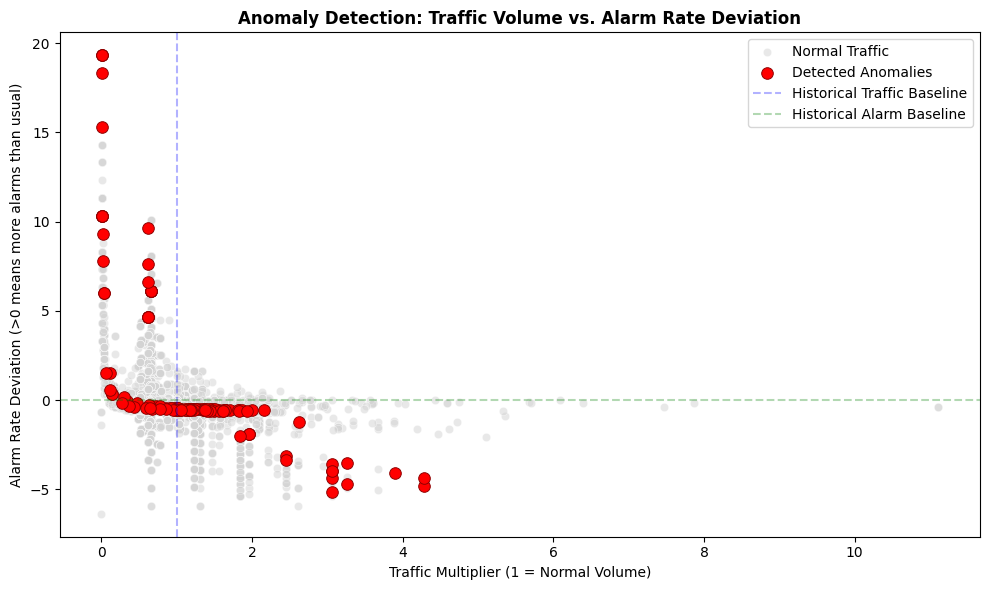

In [22]:
# =====================================================================
# 12. EXPLAINABILITY: VISUALIZING THE ANOMALIES
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot Normal data in grey
sns.scatterplot(
    data=df_master[df_master['anomaly_label'] == 1], 
    x='traffic_multiplier', 
    y='rate_deviation', 
    color='lightgrey', 
    alpha=0.5, 
    label='Normal Traffic'
)

# Plot Anomalies in red
sns.scatterplot(
    data=df_master[df_master['anomaly_label'] == -1], 
    x='traffic_multiplier', 
    y='rate_deviation', 
    color='red', 
    edgecolor='darkred',
    s=70,
    label='Detected Anomalies'
)

plt.title("Anomaly Detection: Traffic Volume vs. Alarm Rate Deviation", fontweight='bold')
plt.xlabel("Traffic Multiplier (1 = Normal Volume)")
plt.ylabel("Alarm Rate Deviation (>0 means more alarms than usual)")
plt.axvline(x=1, color='blue', linestyle='--', alpha=0.3, label='Historical Traffic Baseline')
plt.axhline(y=0, color='green', linestyle='--', alpha=0.3, label='Historical Alarm Baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# =====================================================================
# 13. MODEL COMPARISON: LOCAL OUTLIER FACTOR (LOF)
# =====================================================================
from sklearn.neighbors import LocalOutlierFactor

print("Training the Local Outlier Factor (LOF) model for comparison...")

# Initialize LOF with the same 3% anomaly expectation
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)

# Train and predict (-1 = Anomaly, 1 = Normal)
df_master['anomaly_label_lof'] = lof.fit_predict(X_train)

# Compare the two models
iso_anomalies = len(df_master[df_master['anomaly_label'] == -1])
lof_anomalies = len(df_master[df_master['anomaly_label_lof'] == -1])

# How many anomalies did BOTH models find? (The undeniable anomalies)
consensus = df_master[(df_master['anomaly_label'] == -1) & (df_master['anomaly_label_lof'] == -1)]

print(f"Isolation Forest found : {iso_anomalies} anomalies")
print(f"Local Outlier Factor found : {lof_anomalies} anomalies")
print(f" MODELS CONSENSUS : {len(consensus)} events were flagged by BOTH models!")

# Display the top 3 consensus anomalies
print("\n--- TOP 3 UNDENIABLE ANOMALIES (Flagged by both AI models) ---")
display(consensus[display_cols].head(5))

Training the Local Outlier Factor (LOF) model for comparison...
Isolation Forest found : 141 anomalies
Local Outlier Factor found : 141 anomalies
 MODELS CONSENSUS : 12 events were flagged by BOTH models!

--- TOP 3 UNDENIABLE ANOMALIES (Flagged by both AI models) ---


c:\Users\gmitr\anaconda3\envs\mib_env\lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,departure_date,departure_airport_iata,anomaly_severity_score,entries,total_alarms_day,rate_deviation,traffic_multiplier
2396,2024-02-16 05:45:00,STN,0.003667,7.0,14.0,-4.371423,4.278796
2624,2024-01-03 05:35:00,TIA,0.024343,1.0,19.0,18.314382,0.012795
2682,2024-01-04 12:30:00,TIA,0.014091,52.0,17.0,-0.358695,0.665315
2818,2024-01-07 16:55:00,TIA,0.030660,1.0,20.0,19.314382,0.012795
2966,2024-01-11 05:35:00,TIA,0.087829,1.0,20.0,19.314382,0.012795
